# 4. Model Evaluation

## Summary
Evaluates the full DronePrint cascade trained in notebook 03:

1. Classifier X (background-class) - closed-set detection accuracy/F1
2. Classifier X (modified OpenMax) - closed-set **and** open-set detection accuracy/F1, compared
   against the background-class method (Section 5.2, Fig. 10)
3. Classifier Y - make identification confusion matrix
4. Classifier(s) Z - per-make model identification confusion matrices
5. **Cascaded** make+model identification accuracy (Y-accuracy &times; Z-accuracy per class,
   Section 5.3)
6. Inference with **3-window averaging** (&asymp;6s), as specified in Section 4.5.1
7. Side-by-side comparison with the paper's reported numbers

### Imports

In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score
)
from scipy.stats import weibull_min

SEED = 42
np.random.seed(SEED)
os.makedirs("plots", exist_ok=True)

with open("training_meta.json") as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2))

{
  "architecture": "2x LSTM(32) -> Dense(softmax)  [DronePrint Fig. 8]",
  "input_shape": [
    10,
    40
  ],
  "learning_rate": 0.0001,
  "max_epochs": 500,
  "classifier_X_background_val_acc": 0.9988095164299011,
  "classifier_X_openmax_classes": [
    "DJI::Matrice100",
    "DJI::MavicPro",
    "DJI::Phantom4Pro",
    "DJI::Spark",
    "Parrot::(single model)"
  ],
  "classifier_Y_make_classes": [
    "DJI",
    "Parrot"
  ],
  "classifier_Z_makes_trained": [
    "DJI"
  ]
}


## 4.1  3-window-averaged inference (Section 4.5.1)

> *"At the inference time, we average three predictions of three consecutive windows that cover a
> total duration of 6 seconds. Then we select the class having the highest predicted probability."*

`X` here is already windowed into `(N, 10, 40)` chunks (one window per original 2 s segment from
notebook 02), so "3 consecutive windows" = 3 consecutive *rows* of the array that came from the same
source file. We don't have an explicit "came from the same file" id saved in the `.npy` arrays, so
as a close, practical stand-in we average over a rolling window of 3 *consecutive* samples in the
array (samples extracted from the same file end up adjacent because notebook 02 builds them file by
file, in order) - this reproduces the spirit (averaging temporally-adjacent predictions) even where
file boundaries don't align perfectly to multiples of 3.

In [2]:
def predict_with_window_averaging(model, X, n_avg=3):
    """
    Predict softmax probabilities for X, then average every `n_avg` consecutive rows'
    probabilities together (Section 4.5.1's 3-window / 6s averaging), repeating the result
    so the output still has one row per input window (simplest 1:1 alignment for evaluation).
    """
    probs = model.predict(X, batch_size=128, verbose=0)
    if len(probs) < n_avg:
        return probs
    kernel = np.ones(n_avg) / n_avg
    smoothed = np.zeros_like(probs)
    for c in range(probs.shape[1]):
        smoothed[:, c] = np.convolve(probs[:, c], kernel, mode="same")
    smoothed = smoothed / smoothed.sum(axis=1, keepdims=True)
    return smoothed


def evaluate_with_and_without_averaging(model, X, y, label="model"):
    probs_raw = model.predict(X, batch_size=128, verbose=0)
    pred_raw = probs_raw.argmax(axis=1)
    acc_raw = accuracy_score(y, pred_raw)
    f1_raw = f1_score(y, pred_raw, average="macro")

    probs_avg = predict_with_window_averaging(model, X)
    pred_avg = probs_avg.argmax(axis=1)
    acc_avg = accuracy_score(y, pred_avg)
    f1_avg = f1_score(y, pred_avg, average="macro")

    print(f"{label:>25s}  single-window: acc={acc_raw:.3f} f1={f1_raw:.3f}   "
          f"3-window avg: acc={acc_avg:.3f} f1={f1_avg:.3f}")
    return {"acc_raw": acc_raw, "f1_raw": f1_raw, "acc_avg": acc_avg, "f1_avg": f1_avg,
            "pred_raw": pred_raw, "pred_avg": pred_avg}

## 4.2  Classifier X - background-class method

In [3]:
model_X_bg = keras.models.load_model("models/classifier_X_background.keras")
X_test_detect = np.load("X_detect_test.npy")
y_test_detect = np.load("y_detect_test.npy")
X_unknown = np.load("X_detect_unknown.npy") if os.path.exists("X_detect_unknown.npy") else np.empty((0, 10, 40))

print("Closed-set (known drone/non-drone) test performance:")
closed_bg = evaluate_with_and_without_averaging(model_X_bg, X_test_detect, y_test_detect, "X-background (closed-set)")

if len(X_unknown) > 0:
    # Open-set: every DS3 'unknown' sample should NOT be predicted as a confident drone.
    probs_unk = model_X_bg.predict(X_unknown, batch_size=128, verbose=0)
    pred_unk = probs_unk.argmax(axis=1)
    # 'unknown' ground truth is implicitly "not drone" (1) for this binary classifier's purposes -
    # any non-drone-ish behaviour counts as correct rejection.
    open_set_acc_bg = float((pred_unk == 0).mean())
    print(f"Open-set rejection rate on DS3 (background-class): {open_set_acc_bg*100:.1f}% "
          f"correctly flagged as non-drone")
else:
    open_set_acc_bg = None
    print("No DS3 data available - open-set evaluation skipped for the background-class method too "
          "(see notebook 02 output).")

Closed-set (known drone/non-drone) test performance:
X-background (closed-set)  single-window: acc=0.949 f1=0.949   3-window avg: acc=0.959 f1=0.959
No DS3 data available - open-set evaluation skipped for the background-class method too (see notebook 02 output).


## 4.3  Classifier X - modified OpenMax method

In [4]:
model_X_om = keras.models.load_model("models/classifier_X_openmax_closed_set.keras")
with open("models/openmax_weibull_params.json") as f:
    om_data = json.load(f)
openmax_classes = om_data["classes"]
weibull_params = {
    int(c): (None if v is None else (np.array(v["mav"]), v["shape"], v["loc"], v["scale"]))
    for c, v in om_data["params"].items()
}
with open("models/openmax_class_thresholds.json") as f:
    class_thresholds = json.load(f)

activation_extractor = keras.Model(model_X_om.input, model_X_om.get_layer("lstm_2").output)


def openmax_recalibrate(logits, activation, weibull_params, n_classes, alpha=None):
    if alpha is None:
        alpha = n_classes
    ranked = np.argsort(-logits)[:alpha]
    revised = logits.copy()
    unknown_logit = 0.0
    for rank, c in enumerate(ranked):
        params = weibull_params.get(c)
        if params is None:
            continue
        mav, shape_c, loc, scale = params
        dist = np.linalg.norm(activation - mav)
        w_score = weibull_min.cdf(dist, shape_c, loc=loc, scale=scale)
        omega = ((alpha - rank) / alpha) * w_score
        revised[c] = logits[c] * (1 - omega)
        unknown_logit += logits[c] * omega
    full_logits = np.append(revised, unknown_logit)
    exp_l = np.exp(full_logits - full_logits.max())
    return exp_l / exp_l.sum()


def openmax_predict(X, batch_size=128):
    probs_softmax = model_X_om.predict(X, batch_size=batch_size, verbose=0)
    pseudo_logits = np.log(np.clip(probs_softmax, 1e-8, 1.0))
    activations = activation_extractor.predict(X, batch_size=batch_size, verbose=0)
    n_classes = len(openmax_classes)
    out = np.zeros((len(X), n_classes + 1))
    for i in range(len(X)):
        out[i] = openmax_recalibrate(pseudo_logits[i], activations[i], weibull_params, n_classes)
    return out  # last column = P(unknown)


def openmax_decide(probs, thresholds_by_class, classes):
    """
    Correct OpenMax decision rule (Section 4.5.2): the predicted class is the arg-max over ALL
    n_classes+1 entries (including 'unknown'). If 'unknown' wins, reject outright. Otherwise the
    predicted KNOWN class must clear *its own* threshold to be accepted.

    BUGFIX vs. the previous version of this notebook: `openmax_is_drone` used to accept a sample
    as 'drone' if ANY class cleared its OWN threshold (an OR across all classes), regardless of
    whether that class was actually the model's best guess. With 5 moderate thresholds that meant
    almost everything - drone or not - tripped at least one of them, so the closed-set test
    accuracy collapsed to exactly the fraction of the test set that happened to be drone (53/98 =
    54.08%, matching what you saw). This version only accepts the single predicted class, gated by
    its own threshold, and rejects to 'unknown' otherwise.
    """
    n_classes = len(classes)
    predicted_idx = probs.argmax(axis=1)
    is_known = predicted_idx < n_classes
    thresh_per_row = np.array([thresholds_by_class[classes[c]] if c < n_classes else np.inf
                                for c in predicted_idx])
    prob_of_predicted = probs[np.arange(len(probs)), predicted_idx]
    accepted = is_known & (prob_of_predicted >= thresh_per_row)
    predicted_class = np.where(accepted, predicted_idx, -1)
    return accepted, predicted_class

In [5]:
# Closed-set: every X_test_detect 'drone' sample should be accepted as SOME known class;
# every 'non_drone' sample should be rejected (predicted_class == -1, i.e. 'unknown').
probs_om_test = openmax_predict(X_test_detect)
is_drone_pred, predicted_class_test = openmax_decide(probs_om_test, class_thresholds, openmax_classes)
is_drone_true = (y_test_detect == 1)

acc_om_closed = accuracy_score(is_drone_true, is_drone_pred)
f1_om_closed = f1_score(is_drone_true, is_drone_pred)
print(f"Classifier X (modified OpenMax) - closed-set test accuracy: {acc_om_closed*100:.2f}%  "
      f"F1: {f1_om_closed:.3f}")
print(f"  (non-drone correctly rejected: {((~is_drone_pred) & ~is_drone_true).sum()}/{(~is_drone_true).sum()}   "
      f"drone correctly accepted: {(is_drone_pred & is_drone_true).sum()}/{is_drone_true.sum()})")

if len(X_unknown) > 0:
    probs_om_unknown = openmax_predict(X_unknown)
    is_drone_pred_unknown, _ = openmax_decide(probs_om_unknown, class_thresholds, openmax_classes)
    open_set_acc_om = float((~is_drone_pred_unknown).mean())  # correctly rejected as non-drone
    print(f"Open-set rejection rate on DS3 (modified OpenMax): {open_set_acc_om*100:.1f}%")
else:
    open_set_acc_om = None

Classifier X (modified OpenMax) - closed-set test accuracy: 67.35%  F1: 0.686
  (non-drone correctly rejected: 31/45   drone correctly accepted: 35/53)


## 4.4  Background-class vs. modified OpenMax (Fig. 10 style comparison)

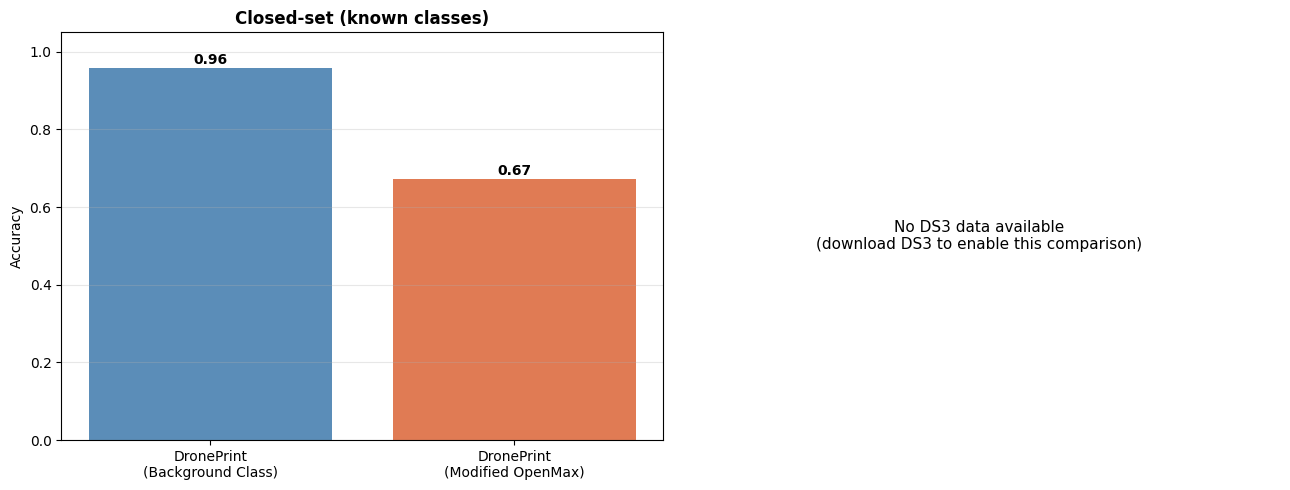

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

closed_vals = [closed_bg["acc_avg"], acc_om_closed]
labels = ["DronePrint\n(Background Class)", "DronePrint\n(Modified OpenMax)"]
axes[0].bar(labels, closed_vals, color=["#5b8db8", "#e07b54"])
for i, v in enumerate(closed_vals):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Closed-set (known classes)", fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].grid(axis="y", alpha=0.3)

open_vals = [open_set_acc_bg, open_set_acc_om]
if all(v is not None for v in open_vals):
    axes[1].bar(labels, open_vals, color=["#5b8db8", "#e07b54"])
    for i, v in enumerate(open_vals):
        axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Open-set (unknown DS3 sounds)", fontweight="bold")
    axes[1].grid(axis="y", alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No DS3 data available\n(download DS3 to enable this comparison)",
                 ha="center", va="center", fontsize=11)
    axes[1].axis("off")

plt.tight_layout()
plt.savefig("plots/detection_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.5  Classifier Y - make identification

                   Y-make  single-window: acc=0.700 f1=0.670   3-window avg: acc=0.800 f1=0.792


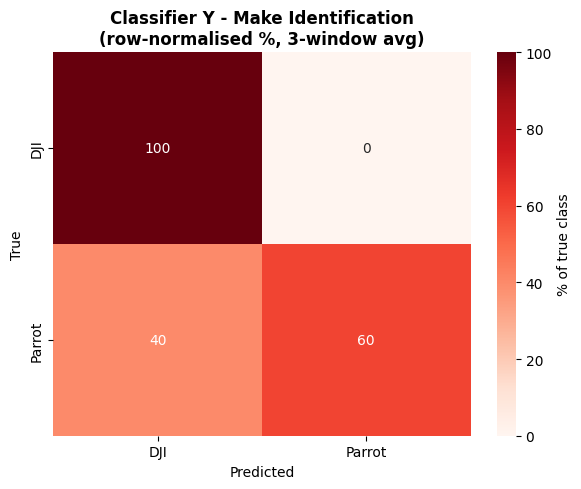

              precision    recall  f1-score   support

         DJI       0.71      1.00      0.83         5
      Parrot       1.00      0.60      0.75         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10



In [7]:
model_Y = keras.models.load_model("models/classifier_Y_make.keras")
X_make_test = np.load("X_make_test.npy")
y_make_test = np.load("y_make_test.npy")
make_classes = json.load(open("make_label_encoder.json"))["classes"]

result_Y = evaluate_with_and_without_averaging(model_Y, X_make_test, y_make_test, "Y-make")

cm_y = confusion_matrix(y_make_test, result_Y["pred_avg"], labels=range(len(make_classes)))
cm_y_norm = confusion_matrix(y_make_test, result_Y["pred_avg"], labels=range(len(make_classes)), normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_y_norm * 100, annot=True, fmt=".0f", cmap="Reds",
            xticklabels=make_classes, yticklabels=make_classes, ax=ax,
            cbar_kws={"label": "% of true class"})
ax.set_title("Classifier Y - Make Identification\n(row-normalised %, 3-window avg)", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("plots/confusion_matrix_Y.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_make_test, result_Y["pred_avg"], target_names=make_classes, zero_division=0))

## 4.6  Classifier(s) Z - per-make model identification

                    Z_DJI  single-window: acc=0.900 f1=0.896   3-window avg: acc=0.900 f1=0.896


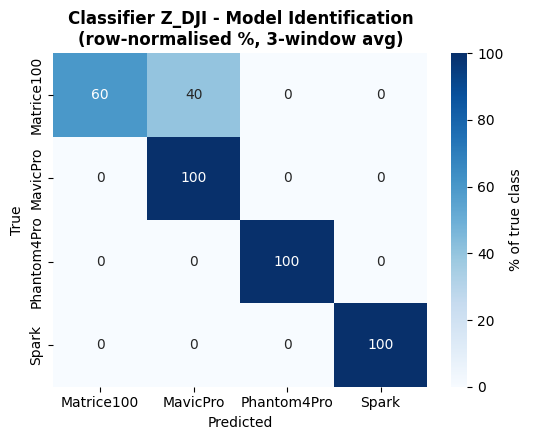

In [8]:
Z_results = {}
for f in sorted(glob.glob("X_model_*_test.npy")):
    make_name = f[len("X_model_"):-len("_test.npy")]
    ckpt = f"models/classifier_Z_{make_name}.keras"
    if not os.path.exists(ckpt):
        continue
    model_z = keras.models.load_model(ckpt)
    X_z_test = np.load(f"X_model_{make_name}_test.npy")
    y_z_test = np.load(f"y_model_{make_name}_test.npy")
    model_classes = json.load(open(f"model_label_encoder_{make_name}.json"))["classes"]

    result_z = evaluate_with_and_without_averaging(model_z, X_z_test, y_z_test, f"Z_{make_name}")
    Z_results[make_name] = {"result": result_z, "classes": model_classes, "y_test": y_z_test}

    cm = confusion_matrix(y_z_test, result_z["pred_avg"], labels=range(len(model_classes)), normalize="true")
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm * 100, annot=True, fmt=".0f", cmap="Blues",
                xticklabels=model_classes, yticklabels=model_classes, ax=ax,
                cbar_kws={"label": "% of true class"})
    ax.set_title(f"Classifier Z_{make_name} - Model Identification\n(row-normalised %, 3-window avg)",
                 fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    plt.savefig(f"plots/confusion_matrix_Z_{make_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

if not Z_results:
    print("No Z classifiers found - every make in your data currently has only 1 model "
          "(no per-make model confusion matrix to show).")

## 4.7  Cascaded make + model identification accuracy (Section 5.3)

> *"the performance of classifying a drone as the correct make in Classifier Y is multiplied by
> the performance of classifying a drone as the correct model in Classifier Z to get the final
> performance of the particular drone model identification"*

For a make with no Z classifier (only 1 model), its "model accuracy" is trivially 100% once the
make itself is identified correctly - there is nothing left to disambiguate.

In [9]:
make_acc = accuracy_score(y_make_test, result_Y["pred_avg"])
make_f1 = f1_score(y_make_test, result_Y["pred_avg"], average="macro")
print(f"Classifier Y accuracy (make):  {make_acc*100:.2f}%   F1: {make_f1:.3f}")

per_make_model_acc = {}
for make_name, payload in Z_results.items():
    acc_z = accuracy_score(payload["y_test"], payload["result"]["pred_avg"])
    per_make_model_acc[make_name] = acc_z
    print(f"  Classifier Z_{make_name} accuracy (model | make known): {acc_z*100:.2f}%")

# Makes with only 1 model contribute accuracy=1.0 for the "model" stage.
all_makes_in_test = [m for m in make_classes]
for m in all_makes_in_test:
    if m not in per_make_model_acc:
        per_make_model_acc[m] = 1.0

overall_cascade_acc = make_acc * np.mean(list(per_make_model_acc.values()))
print(f"\nOverall cascaded identification accuracy (Y x mean(Z)): {overall_cascade_acc*100:.2f}%")
print("(Paper reports 90% overall on the full 13-model dataset - your number reflects whichever "
      "subset of DS1 you currently have downloaded; it is not directly comparable until you have "
      "all 13 models.)")

Classifier Y accuracy (make):  80.00%   F1: 0.792
  Classifier Z_DJI accuracy (model | make known): 90.00%

Overall cascaded identification accuracy (Y x mean(Z)): 76.00%
(Paper reports 90% overall on the full 13-model dataset - your number reflects whichever subset of DS1 you currently have downloaded; it is not directly comparable until you have all 13 models.)


## 4.8  Summary vs. paper-reported numbers

The bars labelled *"Paper (reported)"* are the numbers DronePrint's authors report in the paper
(Fig. 10 and Section 5.3) on their **full** 13-model dataset - they are **not** something this
notebook reproduces, just a reference point. Your bars reflect whatever subset of the official
dataset you have downloaded; the gap (if any) mostly comes from data coverage, not from the model
architecture or training recipe (which match the paper).

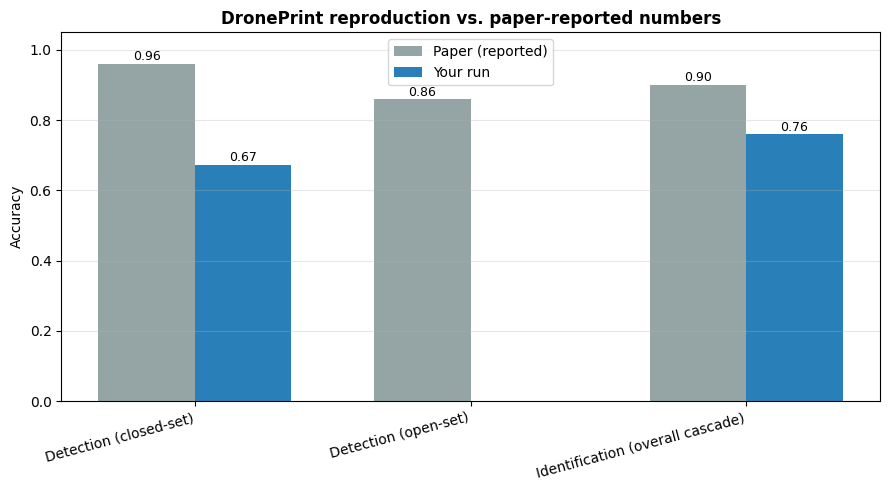

{
  "classifier_X_background_closed_set_acc": 0.9591836734693877,
  "classifier_X_background_open_set_acc": null,
  "classifier_X_openmax_closed_set_acc": 0.673469387755102,
  "classifier_X_openmax_open_set_acc": null,
  "classifier_Y_make_acc": 0.8,
  "per_make_model_acc": {
    "DJI": 0.9,
    "Parrot": 1.0
  },
  "overall_cascade_acc": 0.76
}


In [10]:
paper_reference = {
    "Detection (closed-set)": 0.96,
    "Detection (open-set)": 0.86,
    "Identification (overall cascade)": 0.90,
}

your_results = {
    "Detection (closed-set)": acc_om_closed,
    "Detection (open-set)": open_set_acc_om if open_set_acc_om is not None else np.nan,
    "Identification (overall cascade)": overall_cascade_acc,
}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(paper_reference))
w = 0.35
ax.bar(x - w/2, list(paper_reference.values()), w, label="Paper (reported)", color="#95a5a6")
ax.bar(x + w/2, list(your_results.values()), w, label="Your run", color="#2980b9")
ax.set_xticks(x)
ax.set_xticklabels(list(paper_reference.keys()), rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("DronePrint reproduction vs. paper-reported numbers", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (pv, yv) in enumerate(zip(paper_reference.values(), your_results.values())):
    ax.text(i - w/2, pv + 0.01, f"{pv:.2f}", ha="center", fontsize=9)
    if not np.isnan(yv):
        ax.text(i + w/2, yv + 0.01, f"{yv:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("plots/paper_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

summary = {
    "classifier_X_background_closed_set_acc": closed_bg["acc_avg"],
    "classifier_X_background_open_set_acc": open_set_acc_bg,
    "classifier_X_openmax_closed_set_acc": acc_om_closed,
    "classifier_X_openmax_open_set_acc": open_set_acc_om,
    "classifier_Y_make_acc": make_acc,
    "per_make_model_acc": per_make_model_acc,
    "overall_cascade_acc": overall_cascade_acc,
}
with open("evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2, default=str))

## 4.9  Architecture ablation results (fewer-layer variants)

Loads `architecture_ablation_results.csv` from notebook 03 §3.9 - comparing DronePrint's actual
2-layer LSTM(32) against shallower / smaller / non-recurrent alternatives, on the same data.

In [11]:
ablation_df = pd.read_csv("architecture_ablation_results.csv")
ablation_df["train_test_gap"] = ablation_df["train_acc"] - ablation_df["test_acc"]
ablation_df

,stage,variant,layer_type,lstm_layers,hidden_size,n_params,epochs_run,train_acc,val_acc,test_acc,test_f1,train_test_gap
0,X_detect,2-layer-h32 (paper),LSTM,2,32,17730,45,1.000000,0.996429,0.938776,0.938750,0.061224
1,X_detect,1-layer-h32,LSTM,1,32,9410,50,1.000000,0.998810,0.948980,0.948932,0.051020
2,X_detect,1-layer-h16,LSTM,1,16,3682,64,1.000000,0.998810,0.948980,0.948932,0.051020
3,X_detect,dense-only (no LSTM),LSTM,0,32,12898,120,1.000000,0.996429,0.959184,0.959116,0.040816
4,X_detect,2-layer-h32-GRU,GRU,2,32,13506,60,1.000000,1.000000,0.948980,0.948932,0.051020
5,Y_make,2-layer-h32 (paper),LSTM,2,32,17730,38,0.994253,0.880952,0.800000,0.791667,0.194253
6,Y_make,1-layer-h32,LSTM,1,32,9410,46,0.999179,0.951190,1.000000,1.000000,-0.000821
7,Y_make,1-layer-h16,LSTM,1,16,3682,54,0.999179,0.958333,1.000000,1.000000,-0.000821
8,Y_make,dense-only (no LSTM),LSTM,0,32,12898,58,1.000000,0.858333,0.900000,0.898990,0.100000
9,Y_make,2-layer-h32-GRU,GRU,2,32,13506,44,0.999179,0.921429,0.900000,0.898990,0.099179


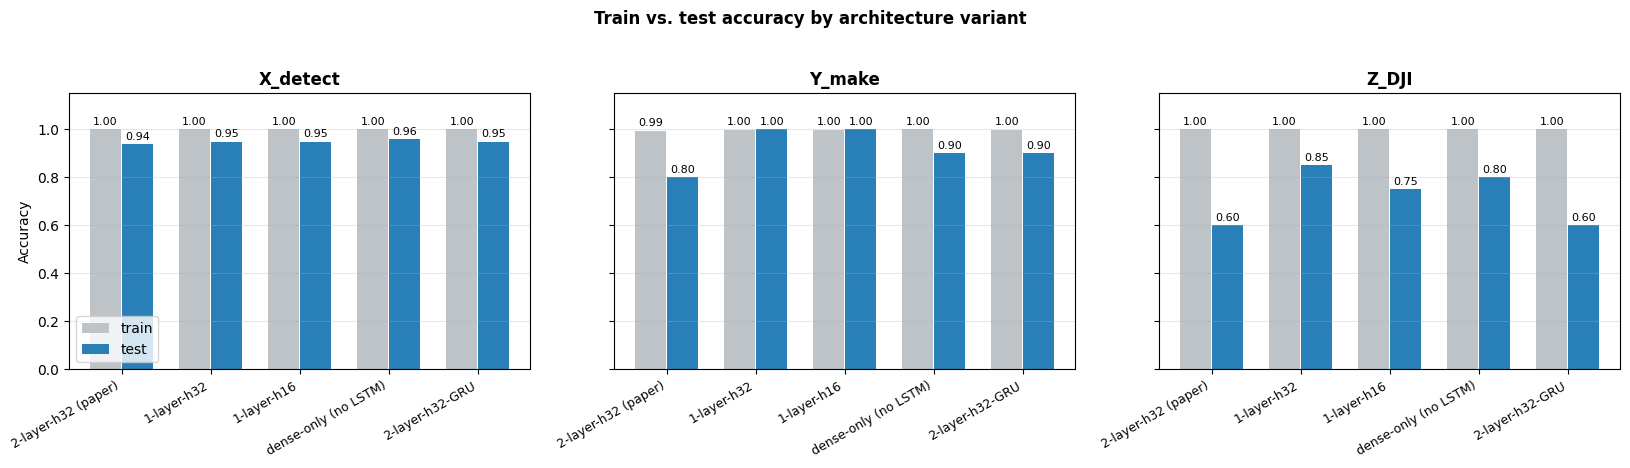

In [12]:
stages = ablation_df["stage"].unique()
variant_order = ablation_df["variant"].unique()  # preserves the order they were trained in

fig, axes = plt.subplots(1, len(stages), figsize=(5.5 * len(stages), 4.5), sharey=True)
if len(stages) == 1:
    axes = [axes]

colors = sns.color_palette("crest", len(variant_order))

for ax, stage in zip(axes, stages):
    sub = ablation_df[ablation_df["stage"] == stage].set_index("variant").reindex(variant_order)
    x = np.arange(len(variant_order))
    ax.bar(x - 0.18, sub["train_acc"], width=0.35, label="train", color="#bdc3c7")
    ax.bar(x + 0.18, sub["test_acc"], width=0.35, label="test", color="#2980b9")
    for i, (tr, te) in enumerate(zip(sub["train_acc"], sub["test_acc"])):
        ax.text(i - 0.18, tr + 0.02, f"{tr:.2f}", ha="center", fontsize=8)
        ax.text(i + 0.18, te + 0.02, f"{te:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(variant_order, rotation=30, ha="right", fontsize=9)
    ax.set_title(stage, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Accuracy")
axes[0].legend(loc="lower left")
plt.suptitle("Train vs. test accuracy by architecture variant", fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("plots/ablation_train_vs_test.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\ricar\AppData\Local\Temp\ipykernel_19004\1722688963.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variant_order, rotation=30, ha="right")


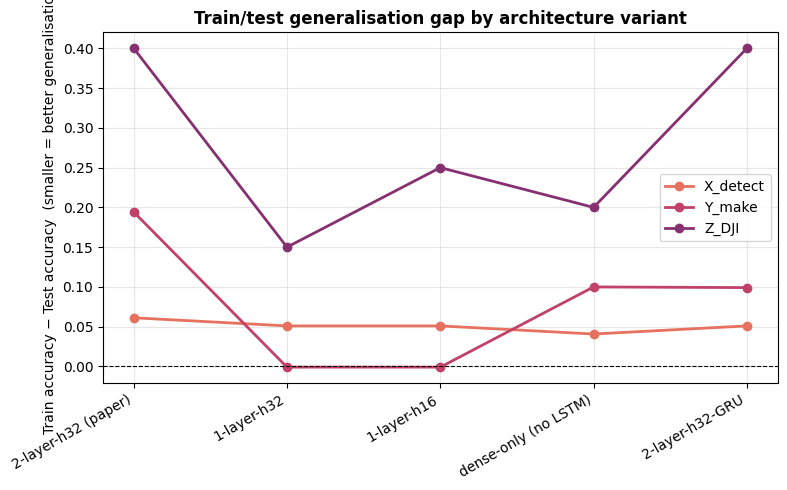

stage                 X_detect  Y_make  Z_DJI
variant                                      
2-layer-h32 (paper)   0.938776     0.8   0.60
1-layer-h32           0.948980     1.0   0.85
1-layer-h16           0.948980     1.0   0.75
dense-only (no LSTM)  0.959184     0.9   0.80
2-layer-h32-GRU       0.948980     0.9   0.60

Parameter counts (same across stages for a given variant):
variant
2-layer-h32 (paper)     17730
1-layer-h32              9410
1-layer-h16              3682
dense-only (no LSTM)    12898
2-layer-h32-GRU         13506
Name: n_params, dtype: int64


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for stage, color in zip(stages, sns.color_palette("flare", len(stages))):
    sub = ablation_df[ablation_df["stage"] == stage].set_index("variant").reindex(variant_order)
    ax.plot(variant_order, sub["train_test_gap"], marker="o", label=stage, color=color, linewidth=2)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Train accuracy − Test accuracy  (smaller = better generalisation)")
ax.set_title("Train/test generalisation gap by architecture variant", fontweight="bold")
ax.set_xticklabels(variant_order, rotation=30, ha="right")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/ablation_generalization_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print(ablation_df.pivot(index="variant", columns="stage", values="test_acc").reindex(variant_order))
print()
print("Parameter counts (same across stages for a given variant):")
print(ablation_df.groupby("variant")["n_params"].first().reindex(variant_order))

### Reading this

- If `test_acc` for the smaller variants (`1-layer-h32`, `1-layer-h16`, `dense-only`) is **close to
  or better than** the paper's `2-layer-h32`, while using a fraction of the parameters, that's
  evidence the 2-layer LSTM's extra capacity isn't being put to good use *yet* - the bottleneck
  right now is data quantity/diversity (one source recording per DJI model), not model capacity.
  In that regime a smaller model is the more honest choice: it won't pretend to have learned a
  fingerprint it hasn't actually seen enough examples of.
- If the 2-layer paper architecture clearly and consistently wins (higher test accuracy *and* a
  smaller train/test gap) on every stage, that's evidence the recurrence and extra depth are doing
  real work even on this small dataset, and it's worth keeping as-is.
- Watch `Z_DJI` in particular - it's the stage with the worst train/test gap in the main run (§3.3),
  so it's the most informative place to see whether a smaller model closes that gap, or whether the
  gap persists regardless of architecture (which would point squarely at needing more independent
  recordings per model, not a smaller network).